In [1]:
import os
import torch
import random
import numpy as np
import pandas as pd
from torch import nn
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision.transforms import v2
import segmentation_models_pytorch as smp
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import Dataset, DataLoader

In [2]:
random.seed(17)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
def build_transforms(crop_size=256, augment=True):
    # paired transforms (image & mask transformed together)
    if augment:
        return v2.Compose([
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),

            v2.RandomCrop(crop_size),
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomVerticalFlip(p=0.2)
        ])
    else:
        return v2.Compose([
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True)
        ])

class CrackSegmentationDataset(Dataset):
    def __init__(self, paths, crop_size=256, augment=True):
        self.paths = paths

        self.images = []
        self.masks = []

        for img_path, mask_path in paths:
            self.images.append(Image.open(img_path).convert("RGB"))
            self.masks.append(Image.open(mask_path).convert("1"))
        
        self.transform = build_transforms(crop_size, augment)
        self.crop_size = crop_size

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image, mask = self.transform(self.images[idx], self.masks[idx])
        return image, mask

In [5]:
class CrackSegmentationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = smp.Unet(
                        encoder_name="efficientnet-b5",        # pretrained backbone
                        encoder_weights="imagenet",            # use ImageNet weights
                        in_channels=3,                         # RGB input
                        classes=1,                             # output channels (binary segmentation)
                    )

    def forward(self, x):
        return self.model(x)

    def name(self):
        return "unet_crack"

In [6]:
def compute_metrics(preds: torch.Tensor, target: torch.Tensor, eps=1e-8):
    """Compute IoU, precision, recall, F1 for binary masks."""
    preds = preds.int()
    target = target.int()

    intersection = (preds & target).sum(dim=(1, 2, 3))
    union = (preds | target).sum(dim=(1, 2, 3))
    iou = (intersection + eps) / (union + eps)

    true_pos = intersection
    false_pos = ((preds == 1) & (target == 0)).sum(dim=(1, 2, 3))
    false_neg = ((preds == 0) & (target == 1)).sum(dim=(1, 2, 3))

    precision = (true_pos + eps) / (true_pos + false_pos + eps)
    recall = (true_pos + eps) / (true_pos + false_neg + eps)
    f1 = 2 * (precision * recall) / (precision + recall + eps)

    return iou.mean().item(), precision.mean().item(), recall.mean().item(), f1.mean().item()

def train_step(model, dataloader, optimizer, scheduler, loss_fn, scaler, device):
    model.train()
    total_loss = 0
    metrics = {"iou": 0, "precision": 0, "recall": 0, "f1": 0}

    for batch, target in dataloader:
        batch, target = batch.to(device), target.to(device)
        optimizer.zero_grad(set_to_none=True)

        with autocast("cuda"):
            logits = model(batch)               # (B,1,H,W)
            loss = loss_fn(logits, target)      # BCEWithLogitsLoss or similar

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

        # Compute metrics
        preds = torch.sigmoid(logits) > 0.5
        iou, precision, recall, f1 = compute_metrics(preds, target)
        metrics["iou"] += iou
        metrics["precision"] += precision
        metrics["recall"] += recall
        metrics["f1"] += f1

    batch_count = len(dataloader)
    avg_loss = total_loss / batch_count
    avg_metrics = {k: v / batch_count for k, v in metrics.items()}

    return avg_loss, avg_metrics


def valid_step(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0
    metrics = {"iou": 0, "precision": 0, "recall": 0, "f1": 0}

    with torch.inference_mode():
        for batch, target in dataloader:
            batch, target = batch.to(device), target.to(device)

            logits = model(batch)
            loss = loss_fn(logits, target)
            total_loss += loss.item()

            preds = torch.sigmoid(logits) > 0.5
            iou, precision, recall, f1 = compute_metrics(preds, target)
            metrics["iou"] += iou
            metrics["precision"] += precision
            metrics["recall"] += recall
            metrics["f1"] += f1

    batch_count = len(dataloader)
    avg_loss = total_loss / batch_count
    avg_metrics = {k: v / batch_count for k, v in metrics.items()}

    return avg_loss, avg_metrics

In [7]:
def train(
    model,
    train_dl,
    valid_dl,
    optimizer,
    scheduler,
    loss_fn,
    epochs,
    device,
    start_checkpoint=None,
    monitor_metric="iou",  # which metric to track for best model
):
    os.makedirs("tmp_model_checkpoints", exist_ok=True)
    scaler = GradScaler()
    
    best_metric = 0.0
    start_epoch = 0
    
    if start_checkpoint:
        start_epoch = start_checkpoint["epoch"] + 1
        best_metric = start_checkpoint.get(f"best_{monitor_metric}", 0.0)
        model.load_state_dict(start_checkpoint["model_state_dict"])
        optimizer.load_state_dict(start_checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(start_checkpoint["scheduler_state_dict"])
        scaler.load_state_dict(start_checkpoint["scaler_state_dict"])

    for epoch in tqdm(range(start_epoch, epochs), desc="Epochs"):
        # ---- Training ----
        train_loss, train_metrics = train_step(model, train_dl, optimizer, scheduler, loss_fn, scaler, device)
        
        # ---- Validation ----
        valid_loss, valid_metrics = valid_step(model, valid_dl, loss_fn, device)

        # ---- Save best model ----
        if valid_metrics[monitor_metric] > best_metric:
            best_metric = valid_metrics[monitor_metric]
            checkpoint = {
                "epoch": epoch,
                f"best_{monitor_metric}": best_metric,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "scaler_state_dict": scaler.state_dict(),
            }
            torch.save(checkpoint, f"tmp_model_checkpoints/best_{monitor_metric}.pth")

        # ---- Save last epoch ----
        if epoch == epochs - 1:
            checkpoint = {
                "epoch": epoch,
                f"best_{monitor_metric}": best_metric,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "scaler_state_dict": scaler.state_dict(),
            }
            torch.save(checkpoint, f"tmp_model_checkpoints/last.pth")

        # ---- Print metrics ----
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Valid loss: {valid_loss:.4f} | "
            f"Valid IoU: {valid_metrics['iou']:.4f} | "
            f"Precision: {valid_metrics['precision']:.4f} | "
            f"Recall: {valid_metrics['recall']:.4f} | "
            f"F1: {valid_metrics['f1']:.4f}"
        )

In [8]:
def list_examples(path: Path):
    # dataset structure:
    # images: $path/images/xxx
    # masks:  $path/masks/xxx
    # return tuples (image_path, mask_path)
    images_path = path / "images"
    masks_path = path / "masks"
    examples = []
    for img_file in images_path.iterdir():
        mask_file = masks_path / img_file.name
        if mask_file.exists():
            examples.append((img_file, mask_file))

    return examples

In [9]:
all_train_examples = list_examples(Path("train"))

# 80 / 20 split for training and validation sets
random.shuffle(all_train_examples)
split_idx = int(0.8 * len(all_train_examples))

train_examples = all_train_examples[:split_idx]
valid_examples = all_train_examples[split_idx:]

test_examples = list_examples(Path("test"))

# take a subset of dataset for quick testing
# rng = random.Random(42)
# train_examples = rng.sample(list_examples(Path("train")), 500)
# test_examples = rng.sample(list_examples(Path("test")), 80)

In [9]:
def compute_class_distribution(example_list):
    total_crack = 0
    total_background = 0

    for img_path, mask_path in tqdm(example_list):
        mask = np.array(Image.open(mask_path).convert("1"), dtype=np.uint8)

        crack_pixels = (mask == 1).sum()
        background_pixels = (mask == 0).sum()

        total_crack += crack_pixels
        total_background += background_pixels

    total_pixels = total_crack + total_background

    return {
        "crack_pixels": int(total_crack),
        "background_pixels": int(total_background),
        "total_pixels": int(total_pixels),
        "crack_ratio": float(total_crack / total_pixels),
        "background_ratio": float(total_background / total_pixels),
    }

In [10]:
compute_class_distribution(train_examples)

  0%|          | 0/7682 [00:00<?, ?it/s]

{'crack_pixels': 53830482,
 'background_pixels': 1487977646,
 'total_pixels': 1541808128,
 'crack_ratio': 0.034913865754377445,
 'background_ratio': 0.9650861342456225}

In [11]:
class_weights = [0.0349481498560452, 0.9650518501439548]
pos_weight = torch.tensor([class_weights[1] / class_weights[0]]).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [12]:
model = CrackSegmentationModel().to(device)

print(f"{len(train_examples)=}, {len(test_examples)=}")

train_dataset = CrackSegmentationDataset(train_examples)
valid_dataset = CrackSegmentationDataset(valid_examples, augment=False)

BATCH_SIZE = 16
EPOCHS = 50

train_dl = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dl = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

optimizer = Adam(model.parameters(), lr=1e-3)
scheduler = OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(train_dl), epochs=EPOCHS)

train(model, train_dl, valid_dl, optimizer, scheduler, loss_fn, EPOCHS, device)

len(train_examples)=7682, len(test_examples)=1695


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 | Train loss: 0.7109 | Valid loss: 0.4378 | Valid IoU: 0.2377 | Precision: 0.2429 | Recall: 0.9588 | F1: 0.3561
Epoch 2/50 | Train loss: 0.4299 | Valid loss: 0.3307 | Valid IoU: 0.2799 | Precision: 0.2853 | Recall: 0.9650 | F1: 0.4047
Epoch 3/50 | Train loss: 0.3648 | Valid loss: 0.3029 | Valid IoU: 0.3043 | Precision: 0.3072 | Recall: 0.9749 | F1: 0.4264
Epoch 4/50 | Train loss: 0.3457 | Valid loss: 0.3777 | Valid IoU: 0.2641 | Precision: 0.2672 | Recall: 0.9752 | F1: 0.3813
Epoch 5/50 | Train loss: 0.3220 | Valid loss: 0.2764 | Valid IoU: 0.3380 | Precision: 0.3407 | Recall: 0.9782 | F1: 0.4640
Epoch 6/50 | Train loss: 0.3128 | Valid loss: 0.2865 | Valid IoU: 0.3116 | Precision: 0.3172 | Recall: 0.9730 | F1: 0.4354
Epoch 7/50 | Train loss: 0.3169 | Valid loss: 0.2768 | Valid IoU: 0.3290 | Precision: 0.3316 | Recall: 0.9793 | F1: 0.4524
Epoch 8/50 | Train loss: 0.3303 | Valid loss: 0.2680 | Valid IoU: 0.3117 | Precision: 0.3144 | Recall: 0.9807 | F1: 0.4369
Epoch 9/50 | Tra

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CrackSegmentationModel().to(device)

checkpoint = torch.load("model_checkpoints/unet_b5.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

model.eval();

In [11]:
def inference(model, images):
    # images: (B, C, H, W)
    with torch.inference_mode():
        logits = model(images)           # (B, 1, H, W)
        probs = torch.sigmoid(logits)    # probabilities of class 1
        return probs

def evaluate_on_dataset(test_dataset):
    total_iou = 0.0
    total_prec = 0.0
    total_rec = 0.0
    total_f1 = 0.0

    for i in tqdm(range(len(test_dataset)), desc="evaluation..."):
        image, mask = test_dataset[i]
        image = image.unsqueeze(0).to(device)      # (1, C, H, W)
        true_mask = mask[None, None].to(device)    # (1, 1, H, W)

        pred_probs = inference(model, image)
        pred_mask = (pred_probs > 0.5).float()     # (1, 1, H, W)

        # ---- use your helper ----
        iou, prec, rec, f1 = compute_metrics(pred_mask, true_mask)

        total_iou  += iou
        total_prec += prec
        total_rec  += rec
        total_f1   += f1

    avg_iou = total_iou / len(test_dataset)
    avg_prec = total_prec / len(test_dataset)
    avg_rec  = total_rec / len(test_dataset)
    avg_f1   = total_f1 / len(test_dataset)

    print(f"Average IoU:  {avg_iou:.4f}")
    print(f"Precision:    {avg_prec:.4f}")
    print(f"Recall:       {avg_rec:.4f}")
    print(f"F1-score:     {avg_f1:.4f}")

evaluation...:   0%|          | 0/1695 [00:00<?, ?it/s]

Average IoU:  0.6086
Precision:    0.6142
Recall:       0.9864
F1-score:     0.6911


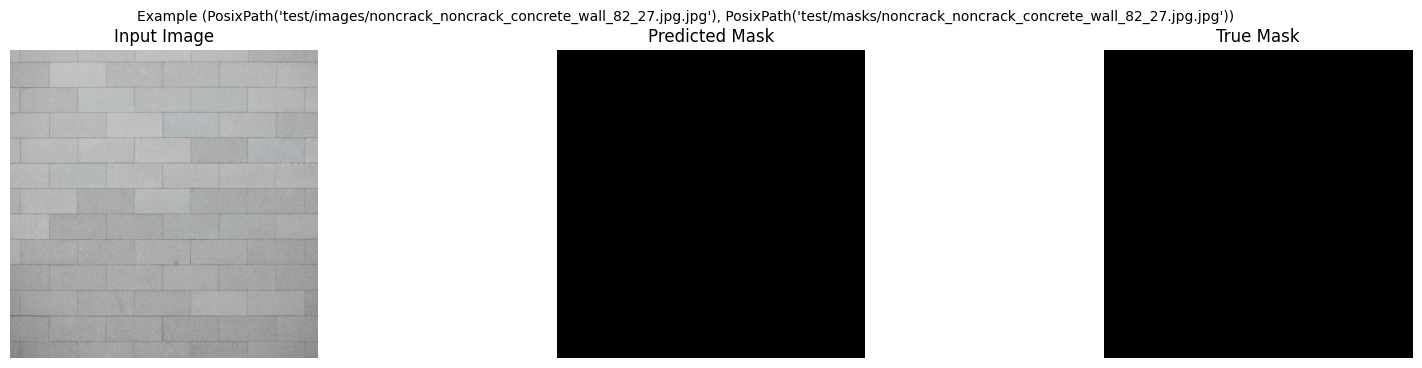

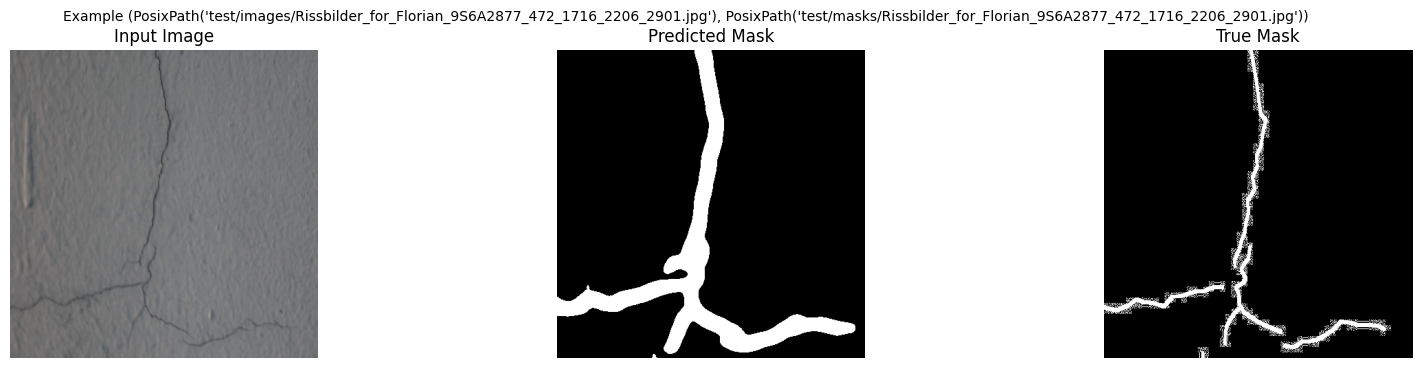

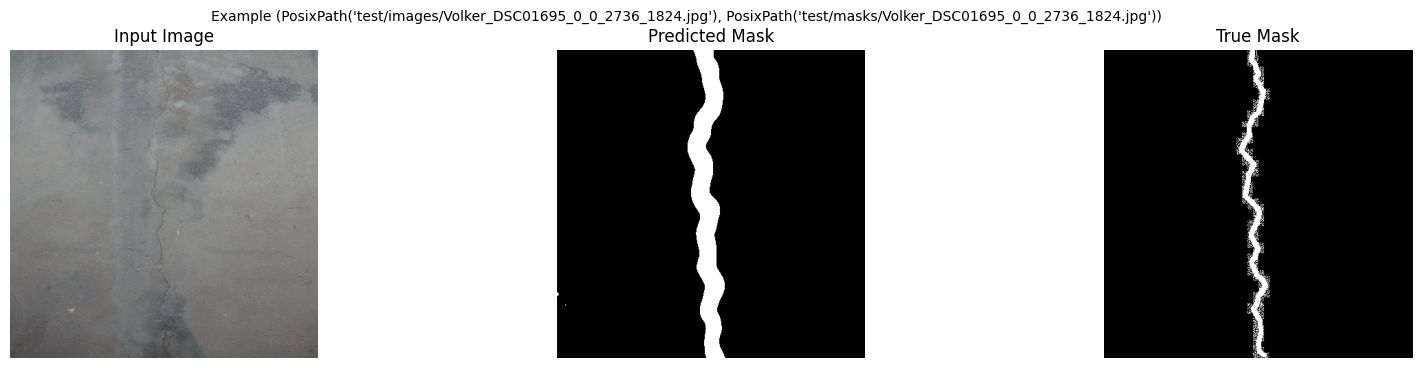

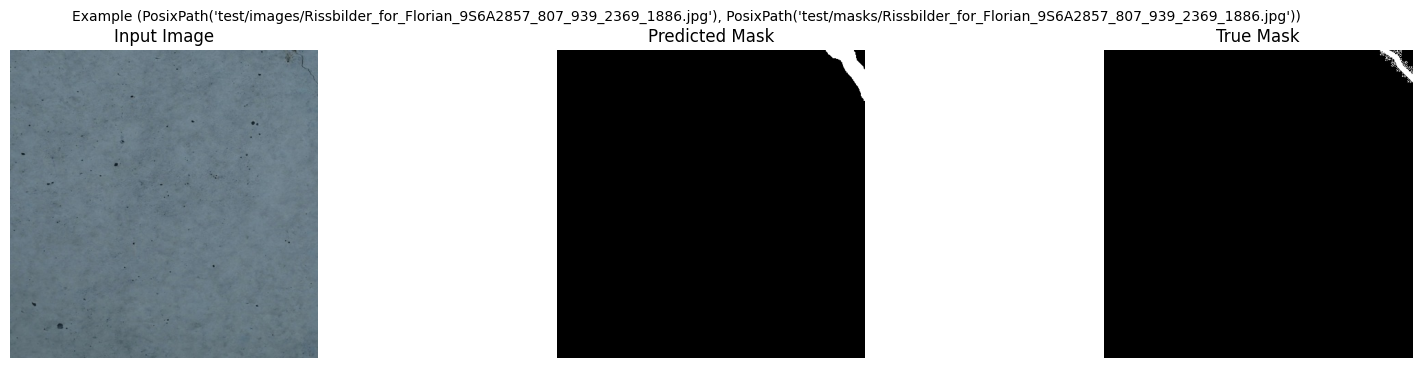

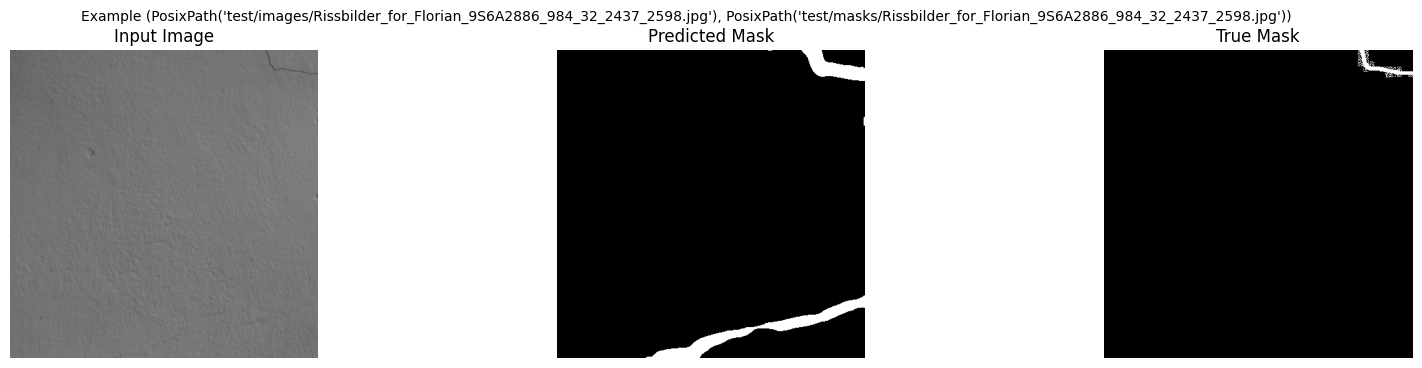

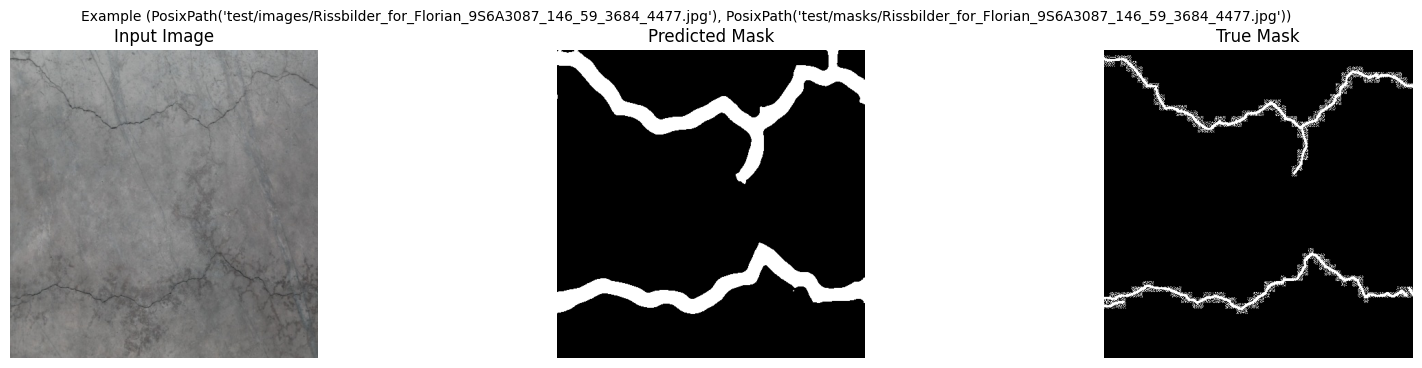

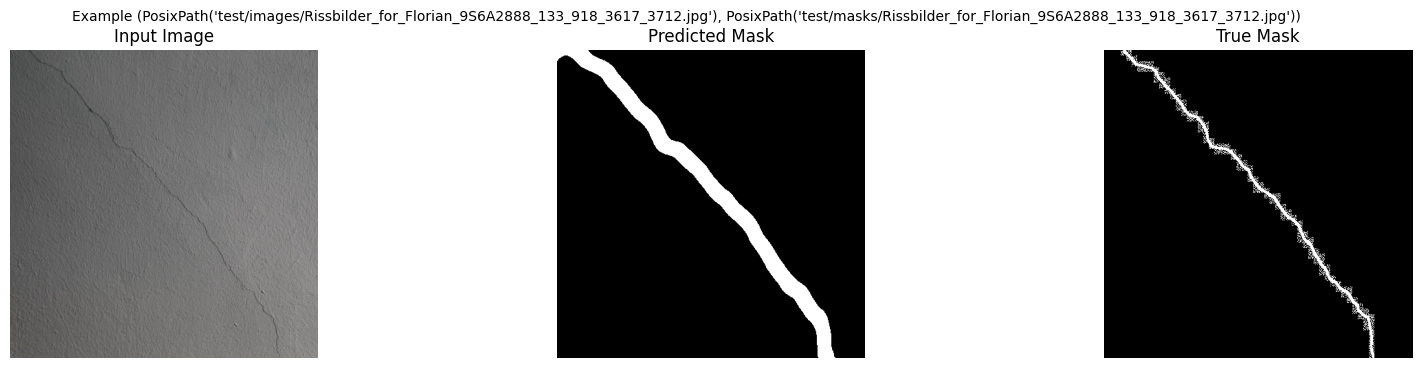

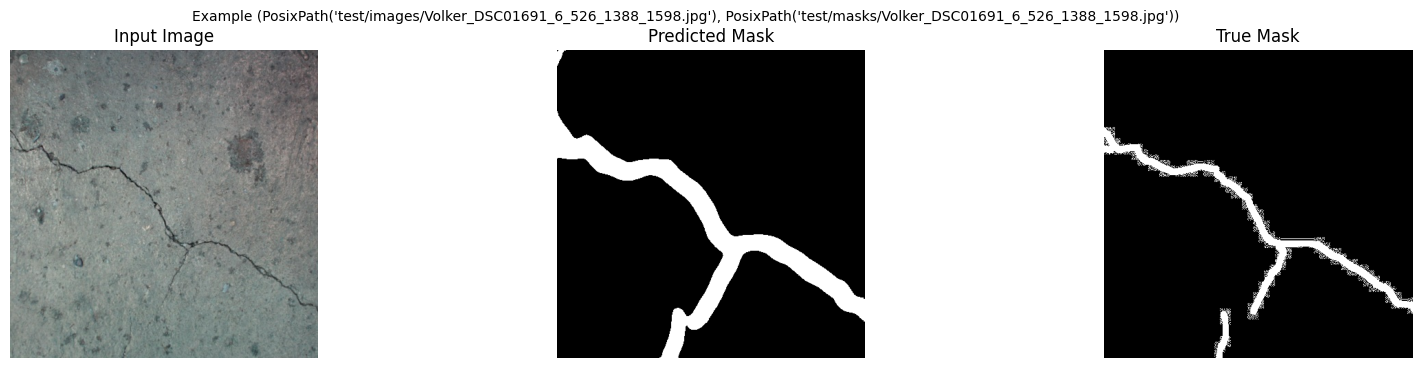

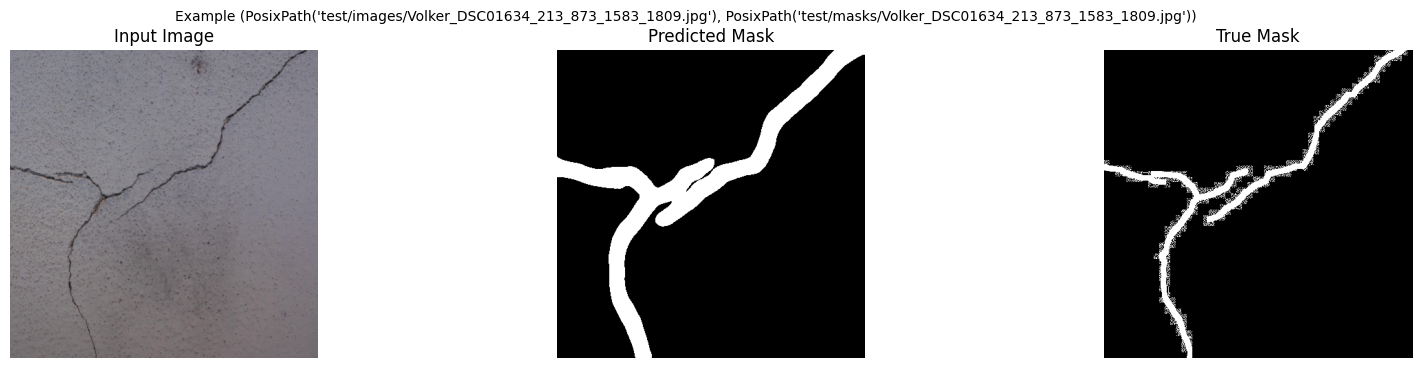

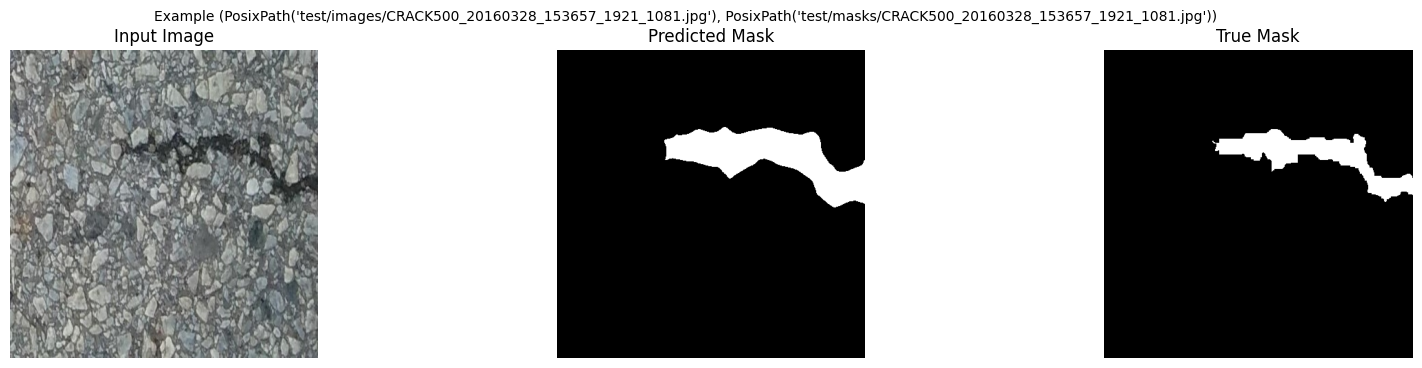

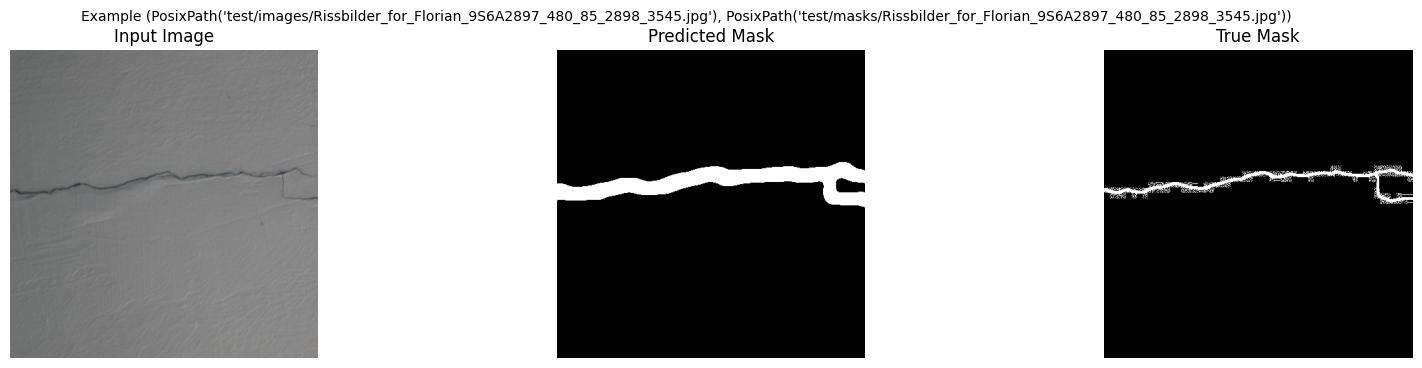

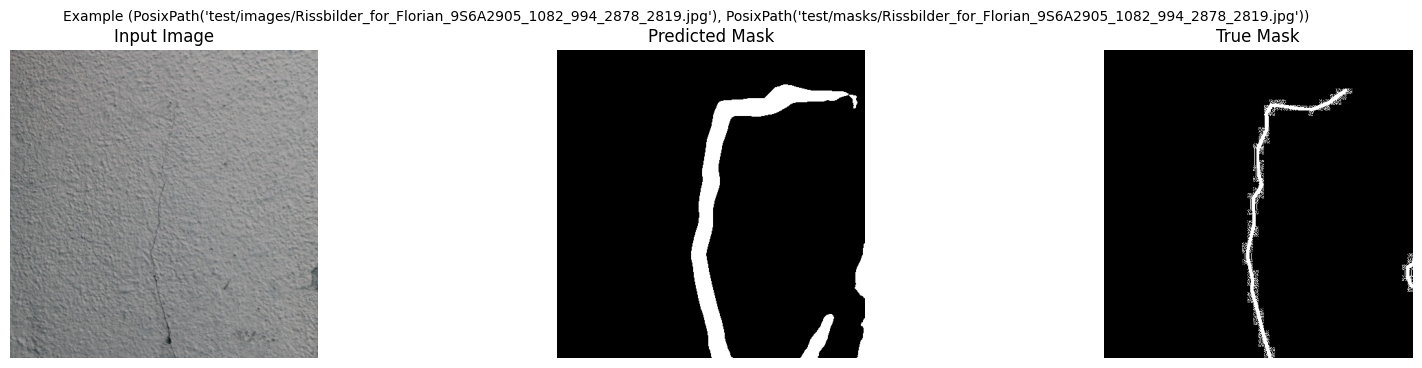

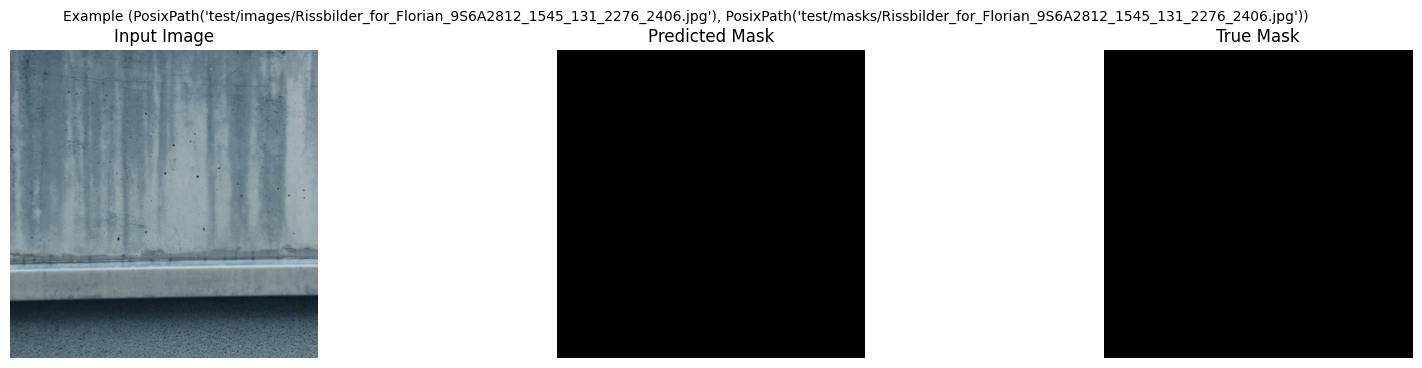

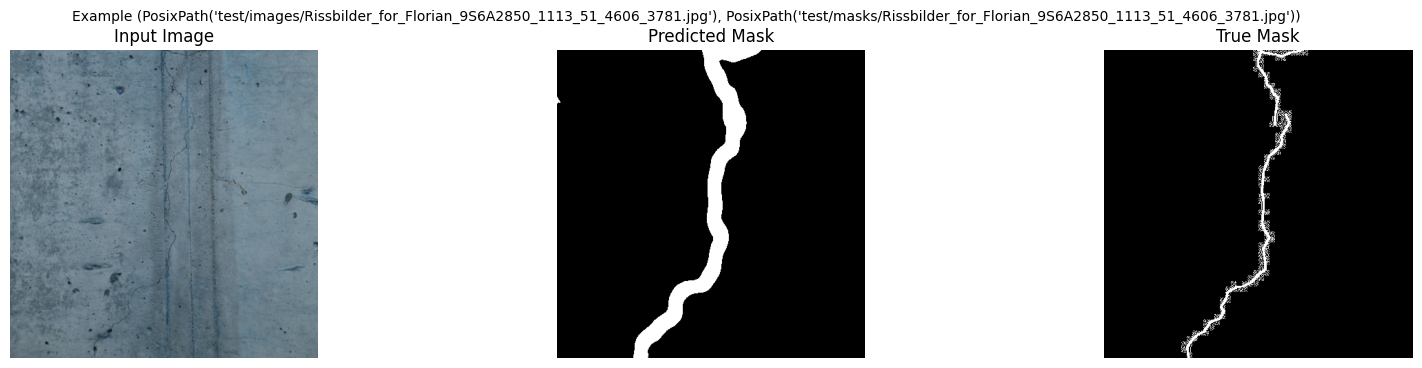

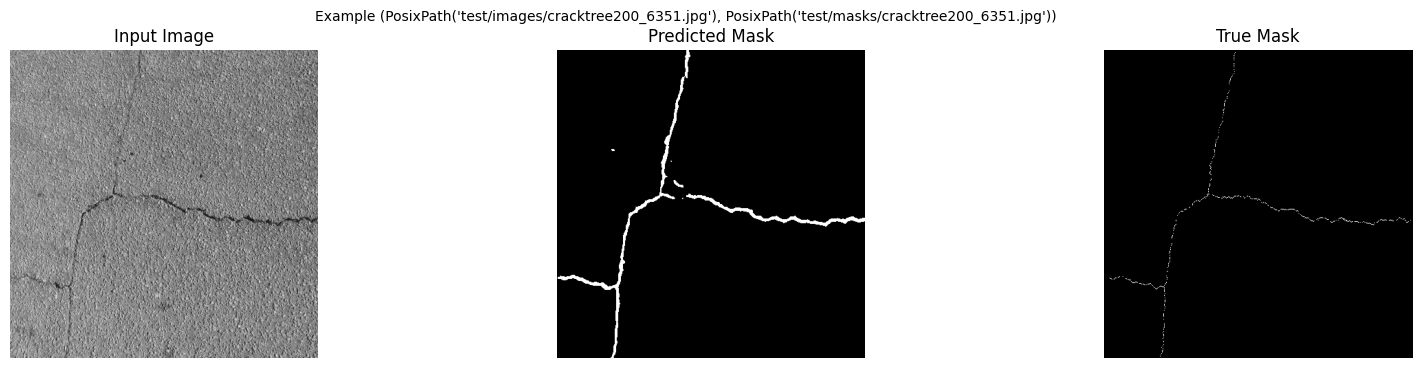

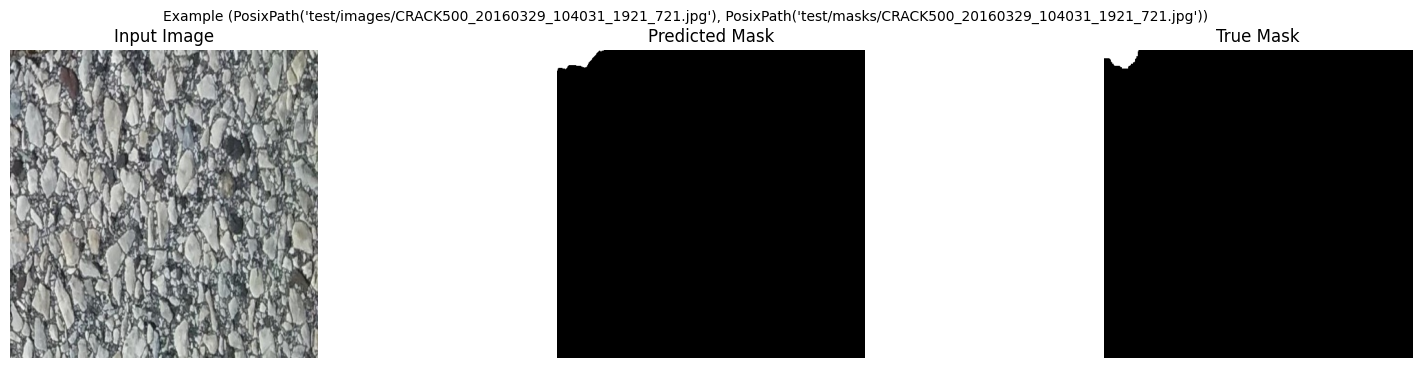

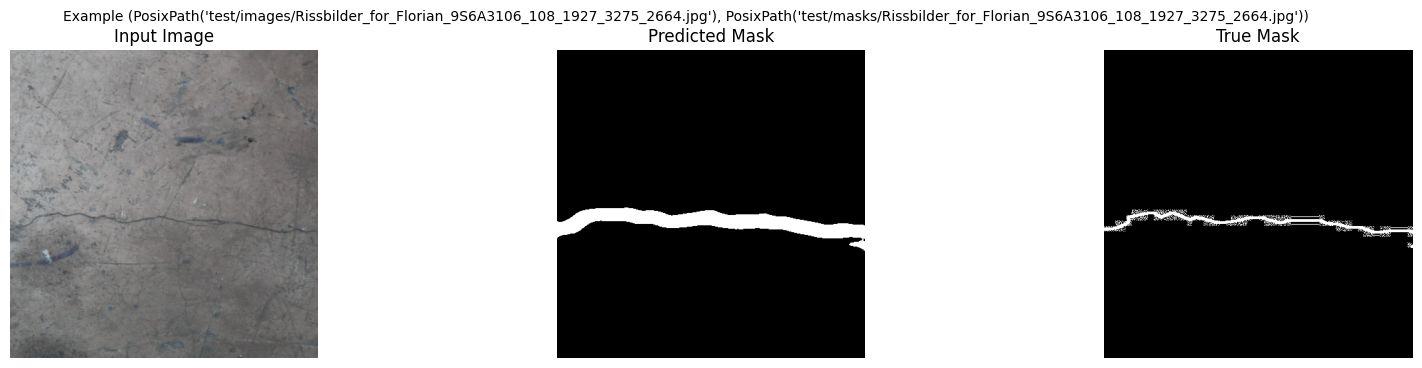

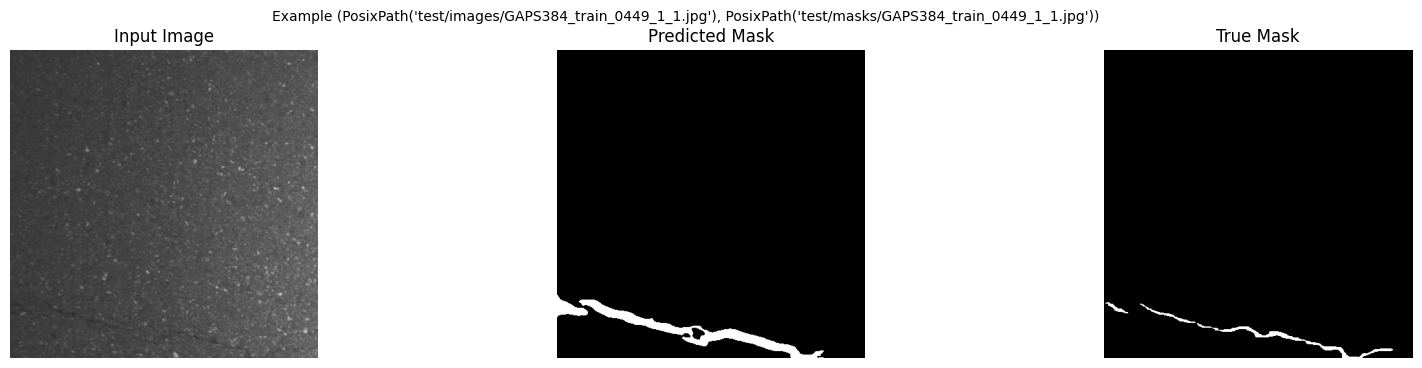

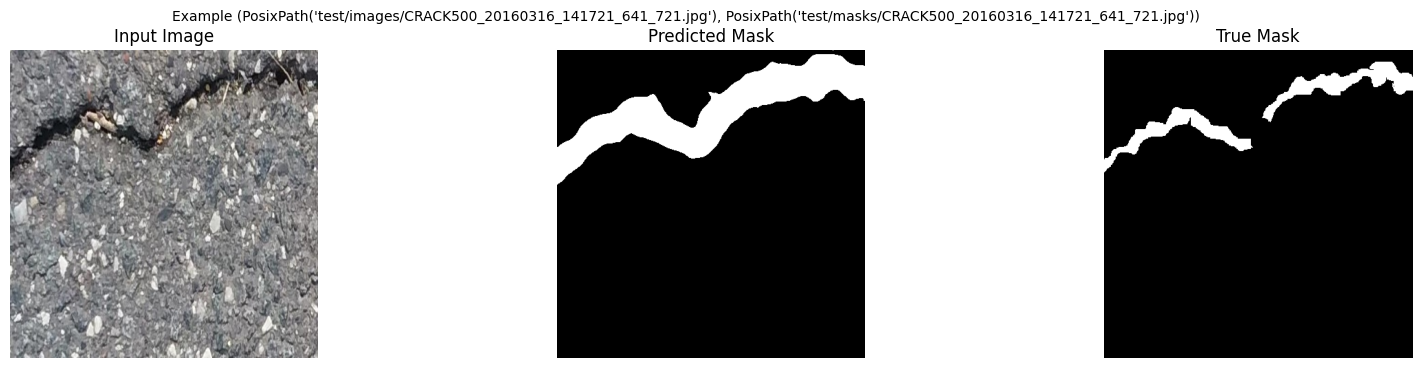

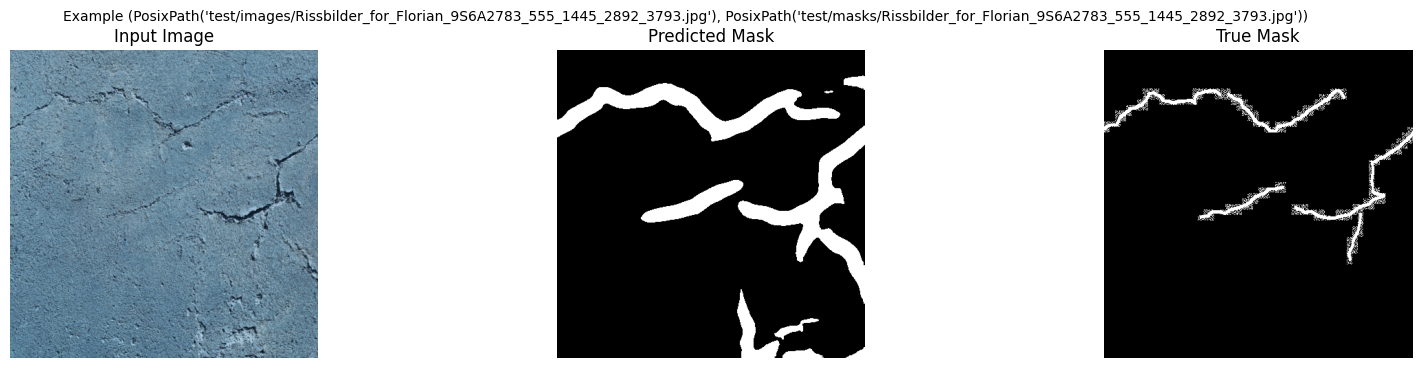

In [14]:
model.eval()
test_examples = list_examples(Path("test"))
test_dataset = CrackSegmentationDataset(test_examples, augment=False)

evaluate_on_dataset(test_dataset)

# visualize
for i in range(20):
    image, mask = test_dataset[i]
    image = image.unsqueeze(0).to(device)
    pred_mask = (inference(model, image) > 0.5).float()

    plt.figure(figsize=(20, 4))
    plt.suptitle(f"Example {test_dataset.paths[i]}", fontsize=10)

    plt.subplot(1, 3, 1)
    plt.title("Input Image")
    plt.imshow(image.squeeze(0).permute(1, 2, 0).cpu().numpy())
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Predicted Mask")
    plt.imshow(pred_mask.squeeze(0).squeeze(0).cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("True Mask")
    plt.imshow(mask.squeeze().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    plt.axis("off")

    plt.show()

Looking at the example predictions, the network’s errors can be attributed to several factors:
- **Imperfect ground truth labels**: Some cracks detected by the model are not marked in the ground truth masks, which makes certain correct predictions appear as errors.
- **Ambiguous material structures**: Variations in the surface texture can resemble cracks, making it difficult to distinguish true cracks from background patterns.
- **Detection of very thin cracks**: The model has difficulty identifying very thin cracks, likely due to their small size relative to the image resolution.
- **Overestimation of crack regions**: The network tends to mark regions larger than the actual cracks. This is likely caused by a combination of the CNN architecture, which naturally produces smooth/expanded activations, and ground truth labels that also mark slightly larger areas than the real cracks, creating ambiguity.

In [14]:
model.eval()
test_examples = list_examples(Path("test"))
test_dataset = CrackSegmentationDataset(test_examples, augment=False)

In [15]:
def mask2rle(img):
    '''
    img: numpy array, 1 -> mask, 0 -> background
    Returns run length as string formated
    '''
    pixels= img.T.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return ' '.join(str(x) for x in runs)

In [16]:
rows = []
batch_size = 16

for i in tqdm(range(0, len(test_dataset), batch_size)):
    batch_indices = list(range(i, min(i + batch_size, len(test_dataset))))
    
    images = torch.stack([test_dataset[idx][0] for idx in batch_indices]).to(device)
    filenames = [Path(test_dataset.paths[idx][0]).name for idx in batch_indices]
    
    pred_masks = (inference(model, images) > 0.5).cpu().numpy()  # (B,H,W)
    
    for filename, pred_mask in zip(filenames, pred_masks):
        cracks = mask2rle(pred_mask > 0.5)
        rows.append({"file": filename, "crack": cracks})

df = pd.DataFrame(rows)
df.to_csv("predicted_cracks.csv", index=False)


  0%|          | 0/106 [00:00<?, ?it/s]

In [17]:
df = pd.DataFrame(rows)
df.to_csv("predicted_cracks.csv", index=False)

In [26]:
sorted(test_examples)[0]

(PosixPath('test/images/CFD_001.jpg'), PosixPath('test/masks/CFD_001.jpg'))

In [20]:
pd.read_csv("predicted_cracks.csv")

,file,crack
0,noncrack_noncrack_concrete_wall_82_27.jpg.jpg,NaN
1,Rissbilder_for_Florian_9S6A2877_472_1716_2206_...,360 28 808 28 1257 27 1706 26 2154 26 2603 25 ...
2,Volker_DSC01695_0_0_2736_1824.jpg,353 6 802 4 1252 1 5747 2 85255 15 85699 22 86...
3,Rissbilder_for_Florian_9S6A2857_807_939_2369_1...,175169 2 175617 3 176065 4 176513 6 176961 7 1...
4,Rissbilder_for_Florian_9S6A2886_984_32_2437_25...,58240 1 58688 1 59135 2 59583 2 60031 2 60479 ...
...,...,...
1690,DeepCrack_11304.jpg,352 2 799 4 1247 3 1696 2 2144 2 3940 2 4111 3...
1691,Rissbilder_for_Florian_9S6A3098_88_800_3751_46...,188 20 636 20 1083 21 1531 21 1979 21 2427 21 ...
1692,GAPS384_train_0455_541_1.jpg,129502 3 129551 2 129950 5 129995 11 130008 30...
1693,CRACK500_20160328_154159_1921_1081.jpg,146 265 598 260 1047 259 1494 261 1943 260 239...


In [30]:
pd.read_csv("sample_submission.csv")

,file,crack
0,CFD_001.jpg,230 8 678 9 1127 8 1578 7 2030 4 2478 6 2926 6...
1,CFD_007.jpg,NaN
2,CFD_011.jpg,175 1 622 2 1070 2 1518 2 1966 2 2414 2 2862 4...
3,CFD_013.jpg,NaN
4,CFD_014.jpg,256 3 701 7 1149 7 1599 5 2047 4 2495 4 2943 3...


                                                file  \
0      noncrack_noncrack_concrete_wall_82_27.jpg.jpg   
1  Rissbilder_for_Florian_9S6A2877_472_1716_2206_...   
2                  Volker_DSC01695_0_0_2736_1824.jpg   
3  Rissbilder_for_Florian_9S6A2857_807_939_2369_1...   
4  Rissbilder_for_Florian_9S6A2886_984_32_2437_25...   

                                               crack  
0                                                NaN  
1  353 58 801 58 1249 58 1697 58 2145 58 2593 58 ...  
2  400 2 848 2 1296 2 1744 2 2192 2 2640 2 3088 2...  
3  173377 17 173825 18 174273 20 174721 22 175169...  
4  166209 16 166657 18 167105 19 167553 21 168001...  


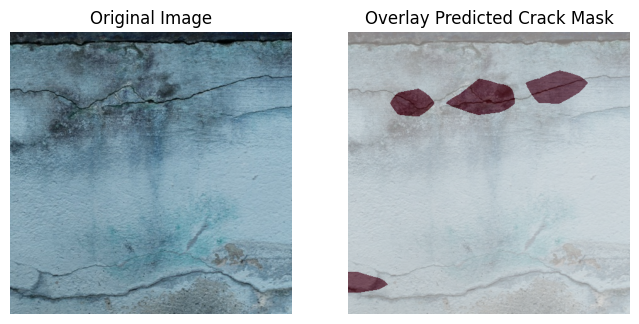

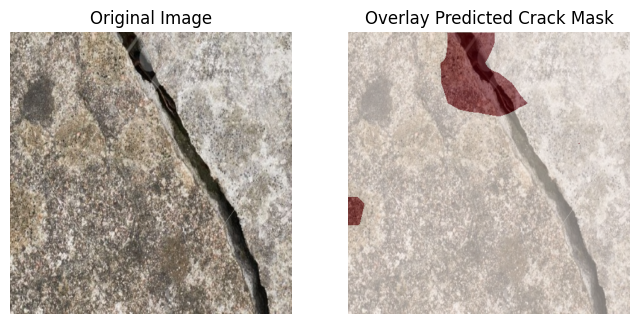

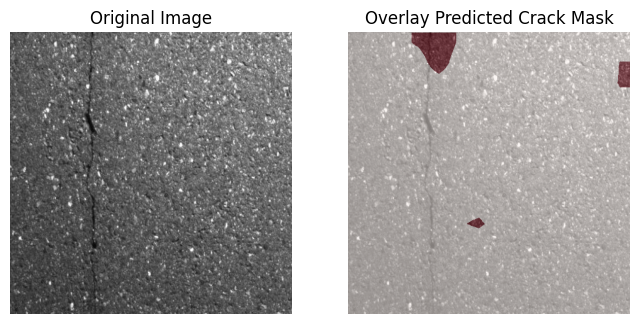

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# --- Load CSV ---
df = pd.read_csv("predicted_cracks.csv")
print(df.head())

# --- Helper: decode RLE into mask ---
def rle_decode(rle, shape):
    """
    rle: string of start length pairs, e.g. "230 8 678 9"
    shape: (H, W)
    """
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    if pd.isna(rle) or rle.strip() == "":
        return mask.reshape(shape)
    
    parts = list(map(int, rle.strip().split()))
    for i in range(0, len(parts), 2):
        start = parts[i]
        length = parts[i+1]
        mask[start:start+length] = 1
    return mask.reshape(shape)

# --- Pick a few examples to visualize ---
example_rows = df.sample(3)  # pick 3 random rows

for _, row in example_rows.iterrows():
    img_path = Path("test/images") / row["file"]  # adjust path if needed
    image = np.array(Image.open(img_path).convert("RGB")) / 255.0  # normalize for visualization
    H, W, _ = image.shape
    
    mask = rle_decode(row["crack"], (H, W))
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(image)
    plt.imshow(mask.T, alpha=0.5, cmap="Reds")
    plt.title("Overlay Predicted Crack Mask")
    plt.axis("off")
    
    plt.show()
